## llama的RoPE实现

In [3]:
import torch

def precompute_freqs_cis(
    head_dim: int,
    seq_len: int,
    theta: float = 10000.0,
    device=None,
):
    """
    预计算 LLaMA RoPE 的复数旋转因子
    返回形状: [seq_len, head_dim // 2] (complex64/complex128)
    """
    assert head_dim % 2 == 0, "head_dim 必须是偶数"
    freqs = 1.0 / (theta ** (torch.arange(0, head_dim, 2, device=device)[:(head_dim//2)].float() / head_dim))
    t = torch.arange(seq_len, device=device).float()
    angles = torch.outer(t, freqs)  # [seq_len, head_dim//2]
    freqs_cis = torch.polar(torch.ones_like(angles), angles)  # e^{i * angle}
    return freqs_cis


def _reshape_for_broadcast(freqs_cis: torch.Tensor, x: torch.Tensor):
    """
    x: [bs, seq_len, n_heads, head_dim//2] (complex)
    freqs_cis: [seq_len, head_dim//2] (complex)
    """
    return freqs_cis.unsqueeze(0).unsqueeze(2)  # [1, seq_len, 1, head_dim//2]


def apply_rotary_emb(
    xq: torch.Tensor,
    xk: torch.Tensor,
    freqs_cis: torch.Tensor,
):
    """
    xq, xk: [bs, seq_len, n_heads, head_dim]
    freqs_cis: [seq_len, head_dim//2]
    返回: 旋转后 xq, xk，形状不变
    """
    assert xq.shape == xk.shape
    bs, seq_len, n_heads, head_dim = xq.shape
    assert head_dim % 2 == 0, "head_dim 必须是偶数"

    # 转为复数表示: [..., head_dim//2, 2] -> complex
    xq_c = torch.view_as_complex(xq.float().reshape(bs, seq_len, n_heads, head_dim // 2, 2))
    xk_c = torch.view_as_complex(xk.float().reshape(bs, seq_len, n_heads, head_dim // 2, 2))

    freqs = _reshape_for_broadcast(freqs_cis[:seq_len].to(xq_c.device), xq_c)

    xq_out = torch.view_as_real(xq_c * freqs).flatten(-2)
    xk_out = torch.view_as_real(xk_c * freqs).flatten(-2)

    return xq_out.type_as(xq), xk_out.type_as(xk)

In [7]:
dim = 17
a = torch.arange(0, dim, 2)
print(a)
print(a[:(dim//2)])
print(dim//2)

tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16])
tensor([ 0,  2,  4,  6,  8, 10, 12, 14])
8


In [ ]:
theta = 10000.0
head_dim = 128
seq_len = 128
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 第i组旋转频率计算 \theta_i
i = torch.arange(0, head_dim, 2, device=device)[:(head_dim//2)].float() / head_dim
# print(i)
freqs = 1.0 / (theta ** i)
print(freqs)

# shape: [1, seq_len]
t = torch.arange(seq_len, device=device).float()
# print(t)

# m的范围是 [0, seq_len-1]
# 提前算出 m*\theta_i 的值，得到一个 [seq_len, head_dim//2] 的矩阵
angles = torch.outer(t, freqs)  # [seq_len, head_dim//2]
print(angles)

# 全部是1，形状和angles一样
o = torch.ones_like(angles)
# 转成极坐标表示，得到复数旋转因子 e^{i * angle}
# freqs_cis = cos(angles) + i*sin(angles)
freqs_cis = torch.polar(o, angles)  # e^{i * angle}
# 0.5403 = cos(1.0)，0.8415 = sin(1.0)
print(freqs_cis)


tensor([1.0000e+00, 9.7630e-01, 9.5316e-01, 9.3057e-01, 9.0852e-01, 8.8699e-01,
        8.6596e-01, 8.4544e-01, 8.2540e-01, 8.0584e-01, 7.8674e-01, 7.6810e-01,
        7.4989e-01, 7.3212e-01, 7.1477e-01, 6.9783e-01, 6.8129e-01, 6.6515e-01,
        6.4938e-01, 6.3399e-01, 6.1897e-01, 6.0430e-01, 5.8997e-01, 5.7599e-01,
        5.6234e-01, 5.4901e-01, 5.3600e-01, 5.2330e-01, 5.1090e-01, 4.9879e-01,
        4.8697e-01, 4.7543e-01, 4.6416e-01, 4.5316e-01, 4.4242e-01, 4.3193e-01,
        4.2170e-01, 4.1170e-01, 4.0195e-01, 3.9242e-01, 3.8312e-01, 3.7404e-01,
        3.6517e-01, 3.5652e-01, 3.4807e-01, 3.3982e-01, 3.3177e-01, 3.2390e-01,
        3.1623e-01, 3.0873e-01, 3.0142e-01, 2.9427e-01, 2.8730e-01, 2.8049e-01,
        2.7384e-01, 2.6735e-01, 2.6102e-01, 2.5483e-01, 2.4879e-01, 2.4289e-01,
        2.3714e-01, 2.3152e-01, 2.2603e-01, 2.2067e-01, 2.1544e-01, 2.1034e-01,
        2.0535e-01, 2.0049e-01, 1.9573e-01, 1.9110e-01, 1.8657e-01, 1.8214e-01,
        1.7783e-01, 1.7361e-01, 1.6950e-

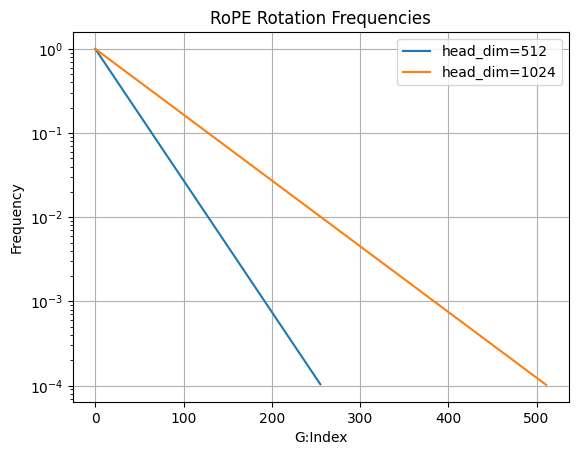

In [54]:
# 画出head=512和1024的旋转频率
import matplotlib.pyplot as plt
head_dims = [512, 1024]
for head_dim in head_dims:
    freqs = 1.0 / (theta ** (torch.arange(0, head_dim, 2, device=device)[:(head_dim//2)].float() / head_dim))
    plt.plot(freqs.cpu().numpy(), label=f'head_dim={head_dim}')
plt.yscale('log')
plt.xlabel('G:Index')
plt.ylabel('Frequency')
plt.title('RoPE Rotation Frequencies')
plt.legend()
plt.grid()
plt.show()

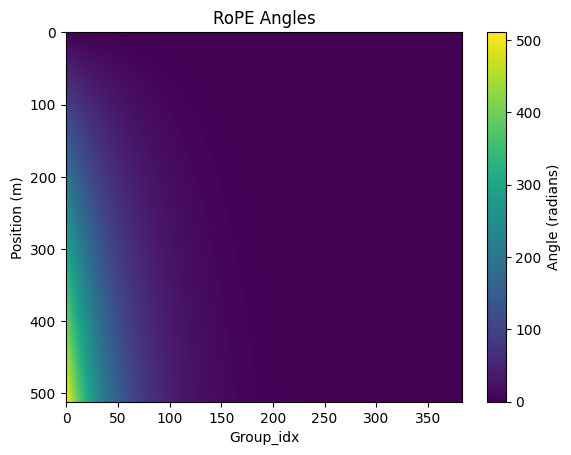

In [56]:
# 画出angles的热力图
plt.imshow(angles.cpu().numpy(), aspect='auto', cmap='viridis')
plt.colorbar(label='Angle (radians)')
plt.xlabel('Group_idx')
plt.ylabel('Position (m)')
plt.title('RoPE Angles')
plt.show()

## Qwen3 的 RoPE实现
大致思路，直接根据简化 $R_m$ 公式把 $\cos\theta$ 和 $\sin\theta$ 提前算出来，分组配对改成  
`0-d/2, 1-d/2+1, d/2-1, d`